In [1]:
!pip install -q Sastrawi gensim mittens deep_translator

In [2]:
import json, re, time, random
from pathlib import Path
from functools import lru_cache
from collections import defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.feature_extraction import text as sklearn_text
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec, FastText
from mittens import GloVe

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER_ID = StemmerFactory().create_stemmer()
except Exception:
    STEMMER_ID = None

# ── Path lokal ────────────────────────────────────────────────────────────────
BASE_DIR     = Path('/home/fatih/Documents/Projects/nlp-dev/nlp-teori')
DATA_PATH    = BASE_DIR / 'dataset' / 'ICAR_Text_Extracted.json'
OUT_DIR      = BASE_DIR / 'output'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'📂 Dataset : {DATA_PATH}')
print(f'📂 Output  : {OUT_DIR}')

# ── Hyperparameter ────────────────────────────────────────────────────────────
VECTOR_SIZE      = 100
WINDOW           = 5
MIN_COUNT        = 2
EPOCHS           = 10
WORKERS          = 4
RANDOM_SEED      = 42
USE_STEMMING     = False

# ── GloVe-specific ────────────────────────────────────────────────────────────
MAX_VOCAB_GLOVE  = 5000   # Batasi vocab → matrix max 5k×5k (~100MB float32)
GLOVE_WINDOW     = 5      # Window size co-occurrence
GLOVE_MAX_ITER   = 100    # Iterasi training GloVe

print(f'✅ Config: vec={VECTOR_SIZE}, window={WINDOW}, min_count={MIN_COUNT}, epochs={EPOCHS}')
print(f'   GloVe: max_vocab={MAX_VOCAB_GLOVE}, window={GLOVE_WINDOW}, max_iter={GLOVE_MAX_ITER}')

📂 Dataset : /home/fatih/Documents/Projects/nlp-dev/nlp-teori/dataset/ICAR_Text_Extracted.json
📂 Output  : /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output
✅ Config: vec=100, window=5, min_count=2, epochs=10
   GloVe: max_vocab=5000, window=5, max_iter=100


In [3]:
stopwords_en  = set(sklearn_text.ENGLISH_STOP_WORDS)
stopwords_id  = {'dan','yang','di','ke','dari','untuk','pada','dengan','atau',
                 'ini','itu','adalah','karena','sebagai','oleh','dalam','juga',
                 'agar','para','kita','kami','mereka','akan','telah','dapat'}
stopwords_all = stopwords_en.union(stopwords_id)

url_pat   = re.compile(r'http\S+|www\.\S+')
digit_pat = re.compile(r'\d+')
alpha_pat = re.compile(r'[^a-zA-Z\s]')
space_pat = re.compile(r'\s+')

@lru_cache(maxsize=100_000)
def stem_token(t): return STEMMER_ID.stem(t) if STEMMER_ID else t

def preprocess_pipeline(text):
    text = text.lower()
    text = url_pat.sub(' ', text)
    text = digit_pat.sub(' ', text)
    text = alpha_pat.sub(' ', text)
    text = space_pat.sub(' ', text).strip()
    if USE_STEMMING and STEMMER_ID:
        text = ' '.join(stem_token(t) for t in text.split())
    tokens = [t for t in text.split() if t not in stopwords_all and len(t) > 2]
    return ' '.join(tokens)

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

rows = []
for category, files in data.items():
    if isinstance(files, dict):
        for fname, txt in files.items():
            rows.append({'category': category, 'doc_id': fname,
                         'text_raw': str(txt) if txt is not None else ''})

df = pd.DataFrame(rows)
df['text_clean'] = df['text_raw'].apply(preprocess_pipeline)
print(f'Loaded {len(df)} dokumen')
print(df[['category', 'doc_id', 'text_clean']].head(3).to_string())

Loaded 159 dokumen
         category                          doc_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [4]:
import shutil
from pathlib import Path
import pandas as pd

AUG_CSV = OUT_DIR / 'icar_augmented.csv'

if AUG_CSV.exists():
    df_aug = pd.read_csv(AUG_CSV)
    print(f'✅ Loaded augmented CSV: {len(df_aug)} baris')
else:
    print('⚠️  icar_augmented.csv tidak ditemukan — mulai augmentasi...')
    from deep_translator import GoogleTranslator

    def back_translate(text, delay=0.5, max_chars=4500):
        try:
            text = str(text).strip()[:max_chars]
            if not text: return text
            en = GoogleTranslator(source='id', target='en').translate(text)
            time.sleep(delay)
            return GoogleTranslator(source='en', target='id').translate(en)
        except Exception as e:
            print(f'  [WARN] {e}')
            return text

    class_dist = df['category'].value_counts()
    max_count  = int(class_dist.max())
    augmented  = []
    random.seed(RANDOM_SEED)

    for cat, count in class_dist.items():
        needed = max_count - count
        if needed == 0:
            print(f'[SKIP] {cat}: {count} docs')
            continue
        print(f'[AUG ] {cat}: {count} → {max_count} (+{needed})')
        samples = df[df['category'] == cat].sample(
            n=needed, replace=needed > count, random_state=RANDOM_SEED)
        for i, (_, row) in enumerate(samples.iterrows()):
            augmented.append({
                'category': row['category'],
                'doc_id': f"{row['doc_id']}_aug{i+1}",
                'text_raw': row['text_raw'],
                'text_clean': back_translate(row['text_clean']),
                'is_augmented': True
            })
        print(f'  ✓ {needed} sampel selesai')

    df_orig = df.copy()
    df_orig['is_augmented'] = False
    df_aug = pd.concat([df_orig, pd.DataFrame(augmented)], ignore_index=True)
    df_aug.to_csv(AUG_CSV, index=False)
    print(f'✅ Augmentasi selesai: {len(df_aug)} baris → {AUG_CSV}')

✅ Loaded augmented CSV: 324 baris


In [5]:
df_aug['text_clean'] = df_aug['text_clean'].fillna('')
sentences = [str(t).split() for t in df_aug['text_clean'] if str(t).strip()]
total_tok = sum(len(s) for s in sentences)
vocab_sz  = len({w for s in sentences for w in s})
print(f'Dokumen : {len(sentences)}')
print(f'Token   : {total_tok:,}')
print(f'Vocab   : {vocab_sz:,}')

Dokumen : 324
Token   : 4,327,495
Vocab   : 110,234


In [6]:
print('⏳ Training Word2Vec Skip-gram...')
w2v_sg = Word2Vec(sentences=sentences, vector_size=VECTOR_SIZE, window=WINDOW,
                  min_count=MIN_COUNT, sg=1, epochs=EPOCHS, workers=WORKERS, seed=RANDOM_SEED)
w2v_sg.save(str(OUT_DIR / 'word2vec_skipgram.model'))
print(f'✅ Skip-gram: vocab={len(w2v_sg.wv):,}, dim={w2v_sg.vector_size}')

print('\n⏳ Training Word2Vec CBOW...')
w2v_cbow = Word2Vec(sentences=sentences, vector_size=VECTOR_SIZE, window=WINDOW,
                    min_count=MIN_COUNT, sg=0, epochs=EPOCHS, workers=WORKERS, seed=RANDOM_SEED)
w2v_cbow.save(str(OUT_DIR / 'word2vec_cbow.model'))
print(f'✅ CBOW: vocab={len(w2v_cbow.wv):,}, dim={w2v_cbow.vector_size}')

⏳ Training Word2Vec Skip-gram...
✅ Skip-gram: vocab=73,036, dim=100

⏳ Training Word2Vec CBOW...
✅ CBOW: vocab=73,036, dim=100


In [7]:
print('⏳ Training FastText...')
ft = FastText(sentences=sentences, vector_size=VECTOR_SIZE, window=WINDOW,
              min_count=MIN_COUNT, epochs=EPOCHS, workers=WORKERS, seed=RANDOM_SEED)
ft.save(str(OUT_DIR / 'fasttext.model'))
print(f'✅ FastText: vocab={len(ft.wv):,}, dim={ft.vector_size}')

⏳ Training FastText...
✅ FastText: vocab=73,036, dim=100


In [8]:
print('⏳ Step 1/3: Membangun vocab GloVe (top frekuensi)...')
word_freq = defaultdict(int)
for sent in sentences:
    for w in sent:
        word_freq[w] += 1

vocab_glove = [
    w for w, c in sorted(word_freq.items(), key=lambda x: -x[1])
    if c >= MIN_COUNT
][:MAX_VOCAB_GLOVE]
word2id = {w: i for i, w in enumerate(vocab_glove)}
V = len(vocab_glove)
print(f'  Vocab: {V:,} kata (dari {len(word_freq):,} unik, dibatasi {MAX_VOCAB_GLOVE})')
print(f'  Estimasi dense matrix: {V}×{V}×4bytes = {V*V*4/1e6:.1f} MB (float32)')

# ─────────────────────────────────────────────────────────────────────────────
print('\n⏳ Step 2/3: Window-based co-occurrence (sparse)...')
cooc  = defaultdict(float)
total = len(sentences)

for idx, sent in enumerate(sentences):
    if idx % 100 == 0:
        print(f'  {idx}/{total} ({100*idx/total:.0f}%)', end='\r')
    token_ids = [word2id[w] for w in sent if w in word2id]
    for i, wi in enumerate(token_ids):
        start = max(0, i - GLOVE_WINDOW)
        end   = min(len(token_ids), i + GLOVE_WINDOW + 1)
        for j in range(start, end):
            if i != j:
                cooc[(wi, token_ids[j])] += 1.0 / abs(i - j)

print(f'\n  Non-zero entries: {len(cooc):,}')
print(f'  Sparsity: {1 - len(cooc)/(V*V):.2%}')

# ─────────────────────────────────────────────────────────────────────────────
print('\n⏳ Step 3/3: Konversi sparse → dense (float32, ukuran terkontrol)...')
ri   = [k[0] for k in cooc]
ci   = [k[1] for k in cooc]
vals = list(cooc.values())
Xc_sp = sp.csr_matrix((vals, (ri, ci)), shape=(V, V))
Xc    = Xc_sp.toarray().astype(np.float32)   # float32 hemat 50% RAM vs float64
del cooc, Xc_sp, ri, ci, vals                 # bebaskan RAM

print(f'✅ Co-occurrence matrix: {Xc.shape}, RAM: {Xc.nbytes/1e6:.1f} MB')

⏳ Step 1/3: Membangun vocab GloVe (top frekuensi)...
  Vocab: 5,000 kata (dari 110,234 unik, dibatasi 5000)
  Estimasi dense matrix: 5000×5000×4bytes = 100.0 MB (float32)

⏳ Step 2/3: Window-based co-occurrence (sparse)...
  300/324 (93%)
  Non-zero entries: 5,717,684
  Sparsity: 77.13%

⏳ Step 3/3: Konversi sparse → dense (float32, ukuran terkontrol)...
✅ Co-occurrence matrix: (5000, 5000), RAM: 100.0 MB


In [9]:
print(f'⏳ Training GloVe (n={VECTOR_SIZE}, max_iter={GLOVE_MAX_ITER})...')
glove_model        = GloVe(n=VECTOR_SIZE, max_iter=GLOVE_MAX_ITER)
embeddings         = glove_model.fit(Xc)
word_vectors_glove = {word: embeddings[i] for i, word in enumerate(vocab_glove)}
print(f'✅ GloVe selesai! Vocab: {len(word_vectors_glove):,}')
print(f'   Contoh vektor "{vocab_glove[0]}": {embeddings[0][:5]}')

# Simpan sebagai .npz
glove_path = OUT_DIR / 'glove_embeddings.npz'
np.savez_compressed(str(glove_path),
                    embeddings=embeddings,
                    vocab=np.array(vocab_glove))
print(f'✅ GloVe disimpan: {glove_path}')

⏳ Training GloVe (n=100, max_iter=100)...


Iteration 100: error 66187.2838

✅ GloVe selesai! Vocab: 5,000
   Contoh vektor "icar": [ 0.7941671   0.09116995 -0.44924966 -0.73604543 -0.77989443]
✅ GloVe disimpan: /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/glove_embeddings.npz


In [10]:
PROBE_WORDS = ['agricultural', 'research', 'water', 'yield', 'soil']

def most_similar_gensim(model, name, words, topn=5):
    print(f'\n{"="*50}\nModel: {name}\n{"="*50}')
    for w in words:
        try:
            sims = model.wv.most_similar(w, topn=topn)
            print(f"  '{w}' → {[(s, round(sc, 3)) for s, sc in sims]}")
        except KeyError:
            print(f"  '{w}' tidak ada dalam vocab")

def most_similar_glove(wv_dict, name, words, topn=5):
    print(f'\n{"="*50}\nModel: {name}\n{"="*50}')
    vocab_list = list(wv_dict.keys())
    mat = np.array(list(wv_dict.values()))
    for w in words:
        if w not in wv_dict:
            print(f"  '{w}' tidak ada dalam vocab GloVe")
            continue
        vec    = wv_dict[w].reshape(1, -1)
        sims   = cosine_similarity(vec, mat)[0]
        idx    = np.argsort(sims)[::-1][1:topn+1]
        result = [(vocab_list[i], round(float(sims[i]), 3)) for i in idx]
        print(f"  '{w}' → {result}")

most_similar_gensim(w2v_sg,   'Word2Vec Skip-gram', PROBE_WORDS)
most_similar_gensim(w2v_cbow, 'Word2Vec CBOW',      PROBE_WORDS)
most_similar_gensim(ft,       'FastText',            PROBE_WORDS)
most_similar_glove(word_vectors_glove, 'GloVe',      PROBE_WORDS)


Model: Word2Vec Skip-gram
  'agricultural' → [('agricul', 0.741), ('education', 0.717), ('taas', 0.716), ('agricultral', 0.714), ('gfq', 0.711)]
  'research' → [('tun', 0.723), ('icfre', 0.723), ('reorganized', 0.721), ('stitute', 0.703), ('cated', 0.702)]
  'water' → [('bandh', 0.735), ('ditches', 0.734), ('percolation', 0.719), ('heaps', 0.713), ('supplemental', 0.713)]
  'yield' → [('yields', 0.801), ('mey', 0.796), ('haulm', 0.787), ('andrographoloid', 0.782), ('tones', 0.778)]
  'soil' → [('moisture', 0.75), ('preserves', 0.744), ('humus', 0.736), ('erosion', 0.734), ('salinization', 0.731)]

Model: Word2Vec CBOW
  'agricultural' → [('michigan', 0.555), ('agricultral', 0.531), ('humanities', 0.513), ('deemed', 0.512), ('presently', 0.508)]
  'research' → [('cognizance', 0.505), ('scientists', 0.499), ('hyderabad', 0.497), ('mandate', 0.486), ('cgiar', 0.486)]
  'water' → [('groundwater', 0.656), ('rainwater', 0.651), ('moisture', 0.642), ('runoff', 0.593), ('surface', 0.587)]
  '

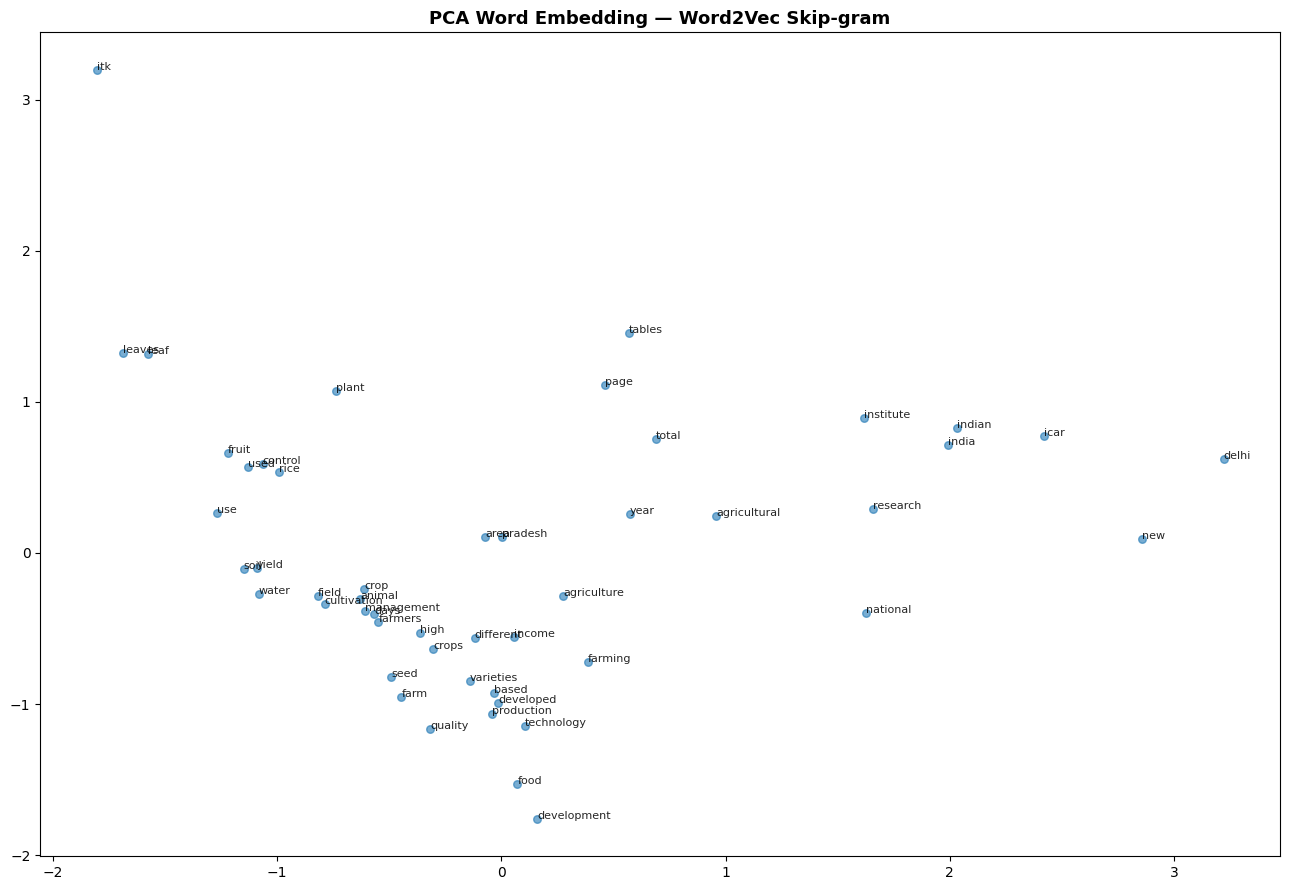

Saved: /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/pca_word_word2vec_skip-gram.png


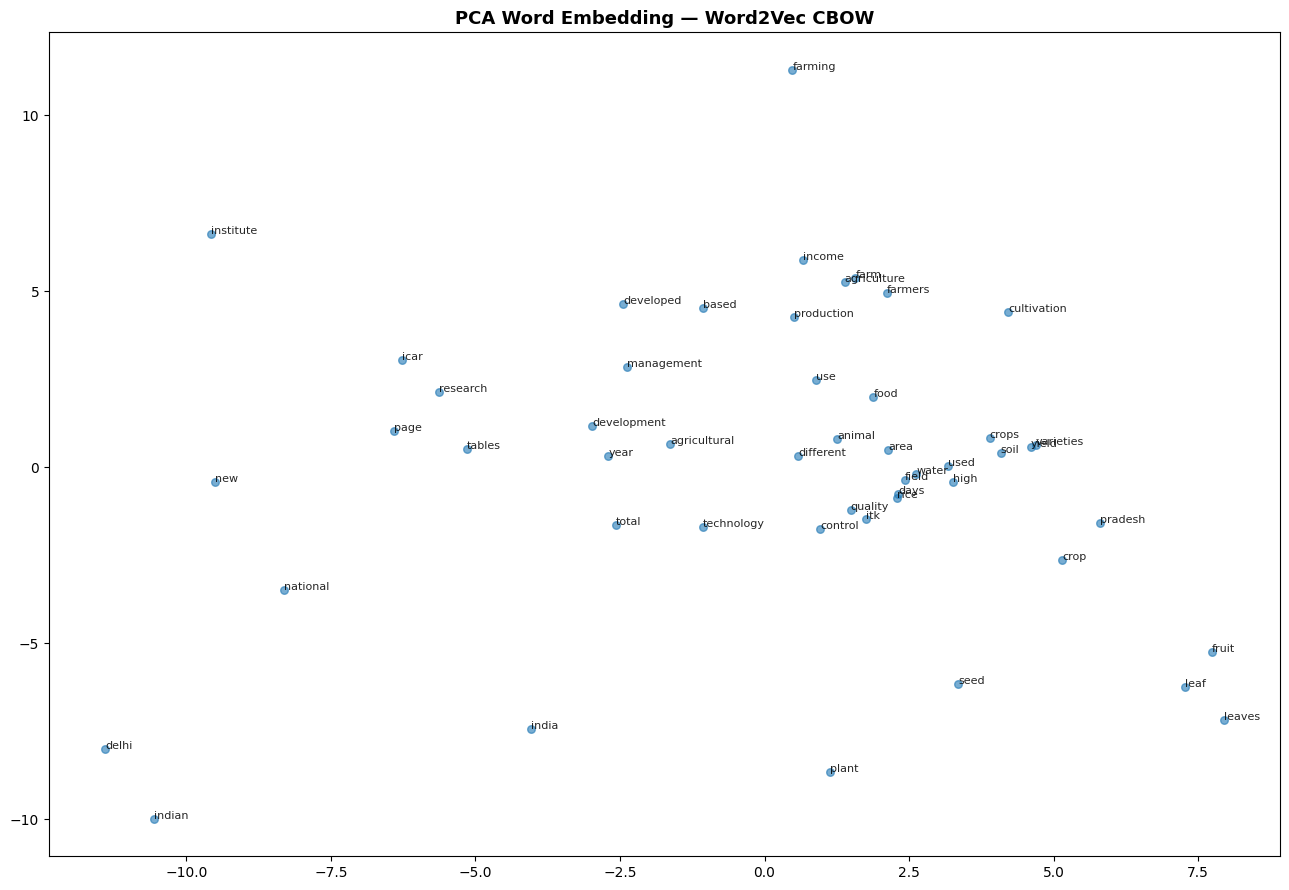

Saved: /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/pca_word_word2vec_cbow.png


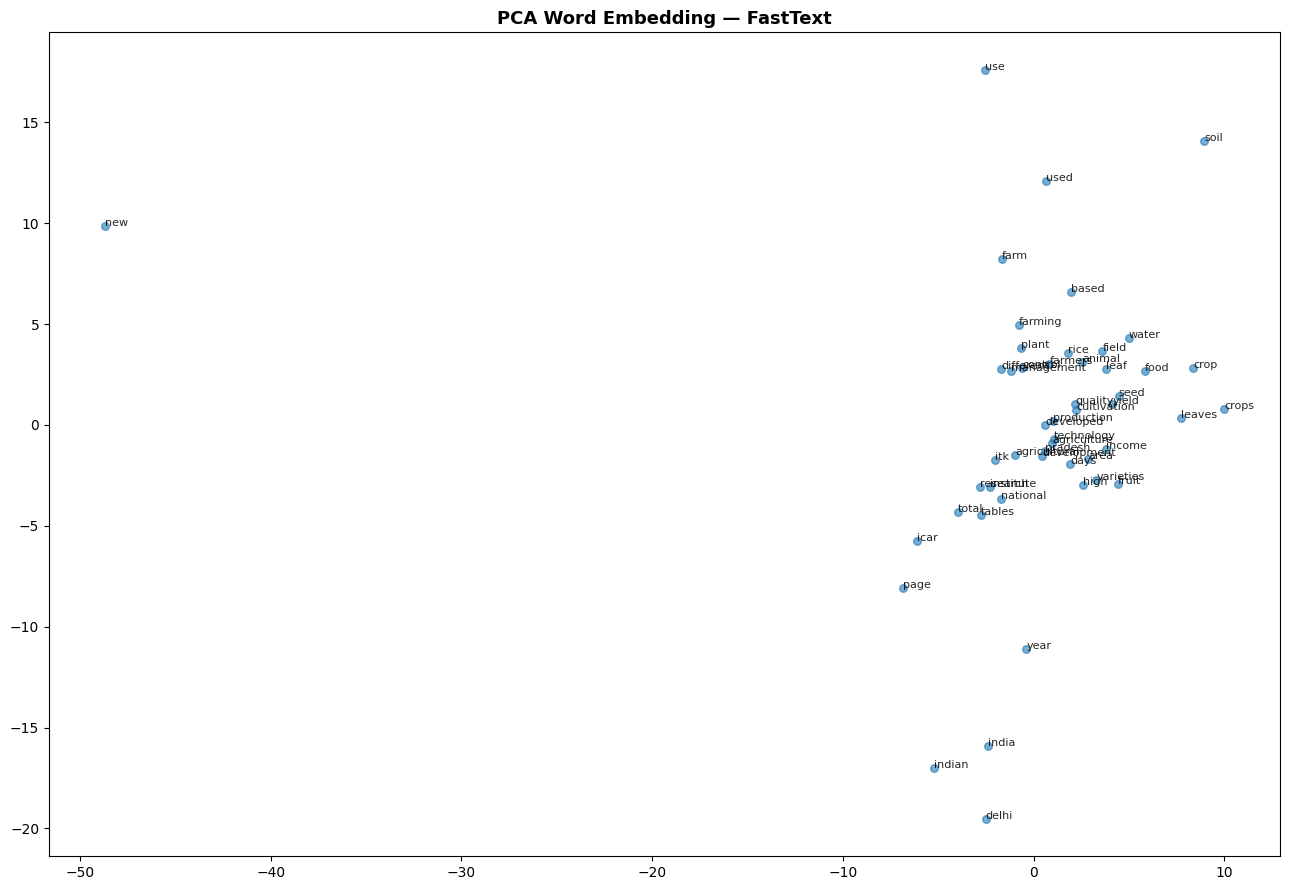

Saved: /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/pca_word_fasttext.png


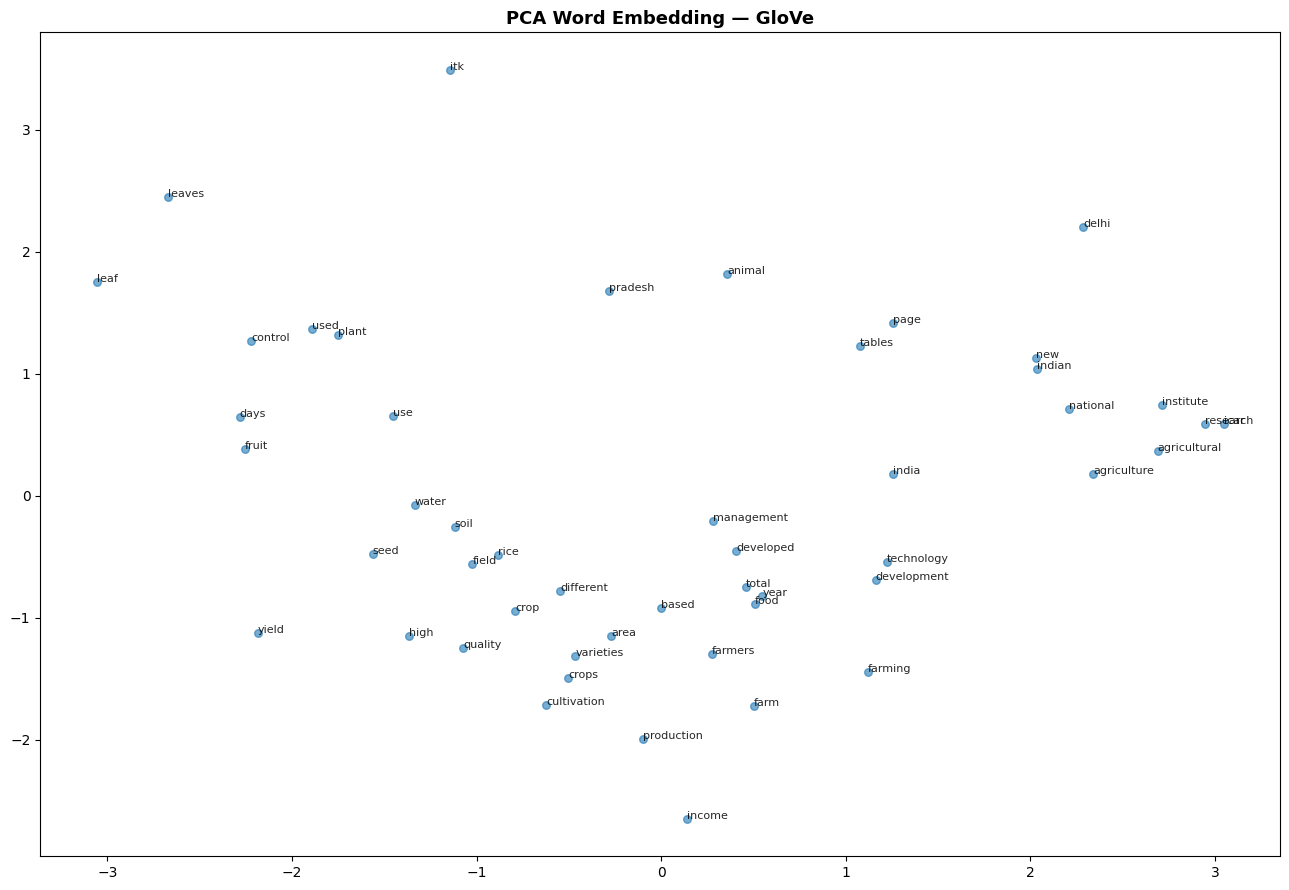

Saved: /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/pca_word_glove.png


In [11]:
TOP_WORDS = 50

def plot_pca_gensim(model, name, top_n=TOP_WORDS):
    words  = list(model.wv.key_to_index.keys())[:top_n]
    vecs   = np.array([model.wv[w] for w in words])
    coords = PCA(n_components=2, random_state=42).fit_transform(vecs)
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=30)
    for i, w in enumerate(words):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.85)
    ax.set_title(f'PCA Word Embedding — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = OUT_DIR / f'pca_word_{name.lower().replace(" ","_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

def plot_pca_glove(wv_dict, name, top_n=TOP_WORDS):
    vocab_list = list(wv_dict.keys())[:top_n]
    vecs  = np.array([wv_dict[w] for w in vocab_list])
    coords = PCA(n_components=2, random_state=42).fit_transform(vecs)
    fig, ax = plt.subplots(figsize=(13, 9))
    ax.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=30)
    for i, w in enumerate(vocab_list):
        ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8, alpha=0.85)
    ax.set_title(f'PCA Word Embedding — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = OUT_DIR / 'pca_word_glove.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

plot_pca_gensim(w2v_sg,   'Word2Vec Skip-gram')
plot_pca_gensim(w2v_cbow, 'Word2Vec CBOW')
plot_pca_gensim(ft,       'FastText')
plot_pca_glove(word_vectors_glove, 'GloVe')

In [12]:
def doc_to_vec_gensim(model, tokens, size):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

def doc_to_vec_glove(wv_dict, tokens, size):
    vecs = [wv_dict[w] for w in tokens if w in wv_dict]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

categories = df_aug['category'].values

model_configs = [
    ('w2v_skipgram', lambda s: doc_to_vec_gensim(w2v_sg,   s, VECTOR_SIZE)),
    ('w2v_cbow',     lambda s: doc_to_vec_gensim(w2v_cbow, s, VECTOR_SIZE)),
    ('fasttext',     lambda s: doc_to_vec_gensim(ft,       s, VECTOR_SIZE)),
    ('glove',        lambda s: doc_to_vec_glove(word_vectors_glove, s, VECTOR_SIZE)),
]

for name, fn in model_configs:
    vecs = np.array([fn(s) for s in sentences])
    cols = [f'dim_{i}' for i in range(vecs.shape[1])]
    tmp  = pd.DataFrame(vecs, columns=cols)
    tmp.insert(0, 'category', categories)
    path = OUT_DIR / f'doc_embeddings_{name}.csv'
    tmp.to_csv(path, index=False)
    print(f'✅ {name}: {vecs.shape} → {path}')


✅ w2v_skipgram: (324, 100) → /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/doc_embeddings_w2v_skipgram.csv
✅ w2v_cbow: (324, 100) → /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/doc_embeddings_w2v_cbow.csv
✅ fasttext: (324, 100) → /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/doc_embeddings_fasttext.csv
✅ glove: (324, 100) → /home/fatih/Documents/Projects/nlp-dev/nlp-teori/output/doc_embeddings_glove.csv
